TRABAJAREMOS SOBRE UN DATASET CON DATOS DE CLIENTES DE UN BANCO.
LA IDEA ES APRENDER A RECONOCER LAS CARACTERÍSTICAS DE LOS CLIENTES MOROSOS, APRENDIENDO DE LAS CARACTERÍSTICAS DEL DATASET.
Los datos se han hecho anónimos para proteger la privacidad de los clientes.


In [1]:
'''
https://jakevdp.github.io/PythonDataScienceHandbook/05.07-support-vector-machines.html
https://ichi.pro/es/hiperparametros-de-svm-explicados-con-visualizaciones-22257741819931#:~:text=Gamma%20es%20un%20hiperpar%C3%A1metro%20utilizado%20con%20SVM%20no,la%20influencia%20de%20un%20solo%20punto%20de%20entrenamiento.
https://www.codificandobits.com/blog/maquinas-de-soporte-vectorial/
https://scikit-learn.org/stable/modules/svm.html#svm
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

'''

# CARGAMOS LAS LIBRERÍAS QUE USAREMOS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve


warnings.filterwarnings("ignore")

In [2]:
credito = pd.read_csv('https://github.com/palasatenea66/DATASETS/raw/main/credito.csv')
print(f'Forma: {credito.shape}')
print(f'Columnas: {credito.columns}')
credito

Forma: (1190, 26)
Columnas: Index(['ID', 'ingresos', 'edad', 'provincia_codigo', 'bancarizado',
       'BCRA_Peor_Situacion', 'Cantidad_consultas_7_dias',
       'Compromisos_Mensual', 'Endeudamiento_Externo', 'Nivel_Socioeconomico',
       'Deuda_normal', 'Deuda_30', 'Deuda_90', 'deuda_120', 'deuda_180',
       'canti_moras', 'autonomo', 'Es_jubilado', 'relacion_dependencia',
       'dias_atraso', 'Cuota', 'cant_cuotas', 'Monto_Otorgado', 'PRODUCTO',
       'PROVINCIA', 'moroso'],
      dtype='object')


,ID,ingresos,edad,provincia_codigo,bancarizado,BCRA_Peor_Situacion,Cantidad_consultas_7_dias,Compromisos_Mensual,Endeudamiento_Externo,Nivel_Socioeconomico,...,autonomo,Es_jubilado,relacion_dependencia,dias_atraso,Cuota,cant_cuotas,Monto_Otorgado,PRODUCTO,PROVINCIA,moroso
0,1,35000.0,35,X,1,1,1.0,9976.0,170000.0,4,...,F,F,UNIVERSIDAD NACIONAL DE CORDOBA ...,143,8957.00,12,50000.0,DS_SUCURSAL_ORO,CORDOBA,1
1,2,50000.0,24,B,1,3,0.0,16807.0,236000.0,4,...,F,F,POLICIA FEDERAL ARGENTINA ...,174,6874.49,9,25000.0,DS_BASICO,BUENOS AIRES,1
2,3,50000.0,42,X,1,1,5.0,42959.0,683343.0,3,...,F,F,MINISTERIO DE EDUCACION ...,0,4191.93,12,23400.0,DS_SUCURSAL_ORO,CORDOBA,0
3,4,32000.0,21,H,1,1,3.0,7583.0,76000.0,5,...,F,F,CONTADURIA GENERAL DEL EJERCITO ...,23,3667.60,12,16000.0,DS_BASICO,CHACO,0
4,5,50000.0,21,Z,1,1,4.0,1040.0,23000.0,5,...,F,F,CONTADURIA GENERAL DEL EJERCITO ...,0,3891.04,6,15000.0,DS_SUCURSAL_ORO,SANTA CRUZ,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1185,1186,50000.0,51,Q,0,0,0.0,0.0,0.0,-1,...,0,0,0,0,5557.65,12,32000.0,DS_REFINANCIACION,NEUQUEN,0
1186,1187,46240.0,32,C,1,1,0.0,3010.0,49000.0,3,...,F,F,POLICIA FEDERAL ARGENTINA ...,0,2594.03,6,10000.0,DS_SUCURSAL_ORO,CAPITAL FEDERAL,0
1187,1188,42866.0,21,B,1,1,18.0,3998.0,46000.0,3,...,F,F,SANOFI PASTEUR SA,58,8957.10,12,50000.0,DS_SUCURSAL_ORO,BUENOS AIRES,0
1188,1189,17000.0,38,B,0,0,0.0,0.0,0.0,-1,...,0,0,0,28,7633.03,6,30000.0,DS_REFINANCIACION,BUENOS AIRES,0


In [3]:
type(credito)

pandas.core.frame.DataFrame

In [4]:
credito.info()   # descripción del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         1190 non-null   int64  
 1   ingresos                   1190 non-null   float64
 2   edad                       1190 non-null   int64  
 3   provincia_codigo           1190 non-null   object 
 4   bancarizado                1190 non-null   int64  
 5   BCRA_Peor_Situacion        1190 non-null   int64  
 6   Cantidad_consultas_7_dias  1189 non-null   float64
 7   Compromisos_Mensual        1190 non-null   float64
 8   Endeudamiento_Externo      1190 non-null   float64
 9   Nivel_Socioeconomico       1190 non-null   int64  
 10  Deuda_normal               1190 non-null   float64
 11  Deuda_30                   1190 non-null   float64
 12  Deuda_90                   1190 non-null   float64
 13  deuda_120                  1190 non-null   float

In [5]:
credito.describe().T   # estadísticos

,count,mean,std,min,25%,50%,75%,max
ID,1190.0,595.500000,343.667717,1.0,298.2500,595.50,892.75,1190.00
ingresos,1190.0,53437.669538,43665.378404,12924.0,33539.6175,47000.00,63000.00,930000.00
edad,1190.0,43.843697,13.781331,18.0,33.0000,42.00,53.00,121.00
bancarizado,1190.0,0.642017,0.479609,0.0,0.0000,1.00,1.00,1.00
BCRA_Peor_Situacion,1190.0,0.889076,1.231544,-1.0,0.0000,1.00,1.00,5.00
Cantidad_consultas_7_dias,1189.0,1.879731,2.768540,0.0,0.0000,1.00,3.00,18.00
Compromisos_Mensual,1190.0,9321.036134,14235.963408,0.0,0.0000,3639.00,13106.00,177911.00
Endeudamiento_Externo,1190.0,152621.008403,240678.479013,0.0,0.0000,54011.50,227061.25,3206484.00
Nivel_Socioeconomico,1190.0,2.902521,2.750135,-1.0,-1.0000,4.00,5.00,7.00
Deuda_normal,1190.0,150607.071429,239969.973391,0.0,0.0000,53000.00,223000.00,3206484.00


In [ ]:
# Veamos qué 'pinta' tiene el dataset
sns.pairplot(credito, hue='moroso', corner=True)   # tarda alrededor de 2 minutos

In [6]:
# VEMOS SI HAY VALORES NULL O NaN
print(f"¿Tiene datos en null o NaN? {credito.isnull().any().any()}")
print("¿Qué columnas poseen null o NaN?")
display(credito.isnull().any())
# TAMBIÉN SE PUEDE PREGUNTAR
print(f'Cuántos registros ausentes hay?\n{credito.isnull().sum()}')

¿Tiene datos en null o NaN? True
¿Qué columnas poseen null o NaN?


,0
ID,False
ingresos,False
edad,False
provincia_codigo,False
bancarizado,False
BCRA_Peor_Situacion,False
Cantidad_consultas_7_dias,True
Compromisos_Mensual,False
Endeudamiento_Externo,False
Nivel_Socioeconomico,False


Cuántos registros ausentes hay?
ID                             0
ingresos                       0
edad                           0
provincia_codigo               0
bancarizado                    0
BCRA_Peor_Situacion            0
Cantidad_consultas_7_dias      1
Compromisos_Mensual            0
Endeudamiento_Externo          0
Nivel_Socioeconomico           0
Deuda_normal                   0
Deuda_30                       0
Deuda_90                       0
deuda_120                      0
deuda_180                      0
canti_moras                    0
autonomo                       0
Es_jubilado                    0
relacion_dependencia         138
dias_atraso                    0
Cuota                          0
cant_cuotas                    0
Monto_Otorgado                 0
PRODUCTO                       0
PROVINCIA                      0
moroso                         0
dtype: int64


In [7]:
# HAY QUE EMPEZAR A TOMAR DECISIONES SOBRE LOS DATOS
# ASIGNAMOS LA COLUMNA 'ID' COMO ÍNDICE DEL DATAFRAME
credito.set_index(['ID'], inplace = True)
# TENEMOS 2 COLUMNAS QUE DESCRIBEN LO MISMO, LA PROVINCIA. ASÍ QUE NOS QUEDAREMOS CON UNA SOLA y eliminaremos la otra
credito.drop(['provincia_codigo'], axis = 1, inplace = True)
print(credito.shape)
credito


(1190, 24)


,ingresos,edad,bancarizado,BCRA_Peor_Situacion,Cantidad_consultas_7_dias,Compromisos_Mensual,Endeudamiento_Externo,Nivel_Socioeconomico,Deuda_normal,Deuda_30,...,autonomo,Es_jubilado,relacion_dependencia,dias_atraso,Cuota,cant_cuotas,Monto_Otorgado,PRODUCTO,PROVINCIA,moroso
ID,,,,,,,,,,,,,,,,,,,,,
1,35000.0,35,1,1,1.0,9976.0,170000.0,4,170000.0,0.0,...,F,F,UNIVERSIDAD NACIONAL DE CORDOBA ...,143,8957.00,12,50000.0,DS_SUCURSAL_ORO,CORDOBA,1
2,50000.0,24,1,3,0.0,16807.0,236000.0,4,187000.0,0.0,...,F,F,POLICIA FEDERAL ARGENTINA ...,174,6874.49,9,25000.0,DS_BASICO,BUENOS AIRES,1
3,50000.0,42,1,1,5.0,42959.0,683343.0,3,683343.0,0.0,...,F,F,MINISTERIO DE EDUCACION ...,0,4191.93,12,23400.0,DS_SUCURSAL_ORO,CORDOBA,0
4,32000.0,21,1,1,3.0,7583.0,76000.0,5,76000.0,0.0,...,F,F,CONTADURIA GENERAL DEL EJERCITO ...,23,3667.60,12,16000.0,DS_BASICO,CHACO,0
5,50000.0,21,1,1,4.0,1040.0,23000.0,5,23000.0,0.0,...,F,F,CONTADURIA GENERAL DEL EJERCITO ...,0,3891.04,6,15000.0,DS_SUCURSAL_ORO,SANTA CRUZ,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1186,50000.0,51,0,0,0.0,0.0,0.0,-1,0.0,0.0,...,0,0,0,0,5557.65,12,32000.0,DS_REFINANCIACION,NEUQUEN,0
1187,46240.0,32,1,1,0.0,3010.0,49000.0,3,49000.0,0.0,...,F,F,POLICIA FEDERAL ARGENTINA ...,0,2594.03,6,10000.0,DS_SUCURSAL_ORO,CAPITAL FEDERAL,0
1188,42866.0,21,1,1,18.0,3998.0,46000.0,3,46000.0,0.0,...,F,F,SANOFI PASTEUR SA,58,8957.10,12,50000.0,DS_SUCURSAL_ORO,BUENOS AIRES,0


In [8]:
# VEAMOS QUÉ VALORES HAY EN 'autonomo' Y 'Es_jubilado'
print(credito['autonomo'].unique())
print(credito['Es_jubilado'].unique())


['F' '0' 'V']
['F' 'V' '0']


In [9]:
credito['Es_jubilado'].replace(to_replace='0', value='F', inplace=True)
credito['autonomo'].replace(to_replace='0', value='F', inplace=True)

In [10]:
credito['autonomo'].unique()

array(['F', 'V'], dtype=object)

In [11]:
# TENEMOS INCONSISTENCIAS EN LOS DATOS EN 'autonomo' Y 'Es_jubilado'. A corregirlas
# DESPUÉS VEMOS QUÉ HACER CON LOS NaN/NULL
credito['autonomo'] = credito.autonomo.map({'F': 0, 'V': 1})
credito['Es_jubilado'] = credito.Es_jubilado.map({'F': 0, 'V': 1})
print(credito['autonomo'].dtype)
print(credito['Es_jubilado'].dtype)
print(credito['autonomo'].unique())
print(credito['Es_jubilado'].unique())

credito.info()

int64
int64
[0 1]
[0 1]
<class 'pandas.core.frame.DataFrame'>
Index: 1190 entries, 1 to 1190
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ingresos                   1190 non-null   float64
 1   edad                       1190 non-null   int64  
 2   bancarizado                1190 non-null   int64  
 3   BCRA_Peor_Situacion        1190 non-null   int64  
 4   Cantidad_consultas_7_dias  1189 non-null   float64
 5   Compromisos_Mensual        1190 non-null   float64
 6   Endeudamiento_Externo      1190 non-null   float64
 7   Nivel_Socioeconomico       1190 non-null   int64  
 8   Deuda_normal               1190 non-null   float64
 9   Deuda_30                   1190 non-null   float64
 10  Deuda_90                   1190 non-null   float64
 11  deuda_120                  1190 non-null   float64
 12  deuda_180                  1190 non-null   float64
 13  canti_moras                11

In [12]:
# VEMOS QUE HAY VALORES AUSENTES EN LA COLUMNA 'relacion_dependencia'
# VAMOS A SUPONER QUE ESOS VALORES AUSENTES CORRESPONDEN A VALORES 0 (PARECE RAZONABLE)
# Es una decisión mía. Pero si pudiera hablar con el cliente, debería averiguar cuál es el caso real,
# pues puede que sean datos ausentes que no se tienen y en ese caso, debería quizás eliminar los registros completos
# ENTONCES RELLENO ESAS COLUMNAS CON 0'S y con esto, ya terminé de asignar valores a los datos ausentes
credito.fillna('0', inplace = True)
credito.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1190 entries, 1 to 1190
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ingresos                   1190 non-null   float64
 1   edad                       1190 non-null   int64  
 2   bancarizado                1190 non-null   int64  
 3   BCRA_Peor_Situacion        1190 non-null   int64  
 4   Cantidad_consultas_7_dias  1190 non-null   object 
 5   Compromisos_Mensual        1190 non-null   float64
 6   Endeudamiento_Externo      1190 non-null   float64
 7   Nivel_Socioeconomico       1190 non-null   int64  
 8   Deuda_normal               1190 non-null   float64
 9   Deuda_30                   1190 non-null   float64
 10  Deuda_90                   1190 non-null   float64
 11  deuda_120                  1190 non-null   float64
 12  deuda_180                  1190 non-null   float64
 13  canti_moras                1190 non-null   int64  
 1

In [13]:
credito['Cantidad_consultas_7_dias']=credito['Cantidad_consultas_7_dias'].astype(int)

In [14]:
credito.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1190 entries, 1 to 1190
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ingresos                   1190 non-null   float64
 1   edad                       1190 non-null   int64  
 2   bancarizado                1190 non-null   int64  
 3   BCRA_Peor_Situacion        1190 non-null   int64  
 4   Cantidad_consultas_7_dias  1190 non-null   int64  
 5   Compromisos_Mensual        1190 non-null   float64
 6   Endeudamiento_Externo      1190 non-null   float64
 7   Nivel_Socioeconomico       1190 non-null   int64  
 8   Deuda_normal               1190 non-null   float64
 9   Deuda_30                   1190 non-null   float64
 10  Deuda_90                   1190 non-null   float64
 11  deuda_120                  1190 non-null   float64
 12  deuda_180                  1190 non-null   float64
 13  canti_moras                1190 non-null   int64  
 1

In [15]:
# REVISAMOS LOS VALORES EN  'relacion_dependencia'
print(credito.autonomo.value_counts())
print(credito.Es_jubilado.value_counts())
print(credito.relacion_dependencia.value_counts())
credito.dtypes
# 'autonomo' y 'Es_jubilado' ya quedaron bien

autonomo
0    1189
1       1
Name: count, dtype: int64
Es_jubilado
0    1068
1     122
Name: count, dtype: int64
relacion_dependencia
0                                                               497
SUPERIOR GOBIERNO DE LA PCIA DE TUCUMAN                          72
CONTADURIA GENERAL DEL EJERCITO                                  60
PROVINCIA DE SALTA                                               46
DIRECCION GENERAL DE CULTURA Y EDUCACIONDE LA PROVINCIA DE B     37
                                                               ... 
MUNICIPALIDAD DE GUAMINI                                          1
NAVAL MOTOR SOCIEDAD ANONIMA                                      1
CORDEIRO Y CIA S R L                                              1
DROGUERIA DEM S.R.L.                                              1
SANOFI PASTEUR SA                                                 1
Name: count, Length: 198, dtype: int64


,0
ingresos,float64
edad,int64
bancarizado,int64
BCRA_Peor_Situacion,int64
Cantidad_consultas_7_dias,int64
Compromisos_Mensual,float64
Endeudamiento_Externo,float64
Nivel_Socioeconomico,int64
Deuda_normal,float64
Deuda_30,float64


In [16]:
# Quiero saber cuántos valores distintos tiene 'relacion_dependencia' (son los nombres de los lugares de trabajo)
print(f'Número de Categorías: { credito.relacion_dependencia.nunique() }')
# hay 198

Número de Categorías: 198


In [17]:
# TENEMOS 3 COLUMNAS DE TIPO 'object'
# PARA 'PROVINCIA' Y 'PRODUCTO' PARECE ADECUADO APLICAR UN ENCODER tipo OneHotEncoder
# PERO 'relacion_dependencia' DESCRIBE CADA LUGAR DE TRABAJO. SIN EMBARGO, NO PARECE IMPORTANTE ESTE HECHO,
# SINO IDENTIFICAR EL TIPO DE ACTIVIDAD DE CADA CLIENTE
# ENTONCES, PARECE MEJOR ASIGNAR 1 AL QUE SEA EMPLEADO Y 0 A QUIEN NO LO SEA
# POR OTRO LADO, EN 'BCRA_Peor_Situacion' SÍ TENEMOS CATEGORÍAS, AUNQUE LA VARIABLE SEA ENTERA.
# lO MISMO EN 'Nivel_Socioeconomico'. ENTONCES PARECE RAZONABLE CODIFICARLOS tipo OneHot
credito['relacion_dependencia'].mask(credito['relacion_dependencia']!='0', 1, inplace=True)
print(credito.relacion_dependencia.value_counts())
print('BCRA\n',credito.BCRA_Peor_Situacion.value_counts())
print('NivSE\n',credito.Nivel_Socioeconomico.value_counts())
credito.info()


relacion_dependencia
1    693
0    497
Name: count, dtype: int64
BCRA
 BCRA_Peor_Situacion
 1    663
 0    359
 5     65
-1     58
 2     21
 4     14
 3     10
Name: count, dtype: int64
NivSE
 Nivel_Socioeconomico
-1    359
 5    255
 4    240
 3    141
 6    127
 7     52
 2     13
 1      3
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 1190 entries, 1 to 1190
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ingresos                   1190 non-null   float64
 1   edad                       1190 non-null   int64  
 2   bancarizado                1190 non-null   int64  
 3   BCRA_Peor_Situacion        1190 non-null   int64  
 4   Cantidad_consultas_7_dias  1190 non-null   int64  
 5   Compromisos_Mensual        1190 non-null   float64
 6   Endeudamiento_Externo      1190 non-null   float64
 7   Nivel_Socioeconomico       1190 non-null   int64  
 8   Deuda_normal

In [18]:
credito['Nivel_Socioeconomico'].unique()

array([ 4,  3,  5,  7,  2,  6,  1, -1])

In [19]:
credito['PRODUCTO'].value_counts()

,count
PRODUCTO,
DS_SUCURSAL_ORO,365
DS_REFINANCIACION,359
DS_BASICO,290
DS_PREMIUM,69
DS_SUCURSAL_PLATA,50
DS_BOT_ORO,32
DS_PLATA,25


In [20]:
# AHORA APLICAREMOS EL CODIFICADO. PANDAS TIENE UN MÉTODO LLAMADO GET_DUMMIES QUE HACE LO MISMO QUE OneHot
# (y no vamos a necesitar hacer conversiones de matrices de np a dataframe y de vuelta)
# PRIMERO HAY CAMBIAR EL TIPO DE LAS COLUMNAS A TRANSFORMAR A 'object' O 'category'

columnas_cod=['PRODUCTO', 'PROVINCIA', 'BCRA_Peor_Situacion', 'Nivel_Socioeconomico']
# asignamos los tipos correctos
credito[columnas_cod] = credito[columnas_cod].astype(str)
credito[['relacion_dependencia', 'autonomo', 'Es_jubilado']]=credito[['relacion_dependencia', 'autonomo', 'Es_jubilado']].astype(int)  #  son enteros pero sin tipo int
credito.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1190 entries, 1 to 1190
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ingresos                   1190 non-null   float64
 1   edad                       1190 non-null   int64  
 2   bancarizado                1190 non-null   int64  
 3   BCRA_Peor_Situacion        1190 non-null   object 
 4   Cantidad_consultas_7_dias  1190 non-null   int64  
 5   Compromisos_Mensual        1190 non-null   float64
 6   Endeudamiento_Externo      1190 non-null   float64
 7   Nivel_Socioeconomico       1190 non-null   object 
 8   Deuda_normal               1190 non-null   float64
 9   Deuda_30                   1190 non-null   float64
 10  Deuda_90                   1190 non-null   float64
 11  deuda_120                  1190 non-null   float64
 12  deuda_180                  1190 non-null   float64
 13  canti_moras                1190 non-null   int64  
 1

In [ ]:
credito.columns

Index(['ingresos', 'edad', 'bancarizado', 'BCRA_Peor_Situacion',
       'Cantidad_consultas_7_dias', 'Compromisos_Mensual',
       'Endeudamiento_Externo', 'Nivel_Socioeconomico', 'Deuda_normal',
       'Deuda_30', 'Deuda_90', 'deuda_120', 'deuda_180', 'canti_moras',
       'autonomo', 'Es_jubilado', 'relacion_dependencia', 'dias_atraso',
       'Cuota', 'cant_cuotas', 'Monto_Otorgado', 'PRODUCTO', 'PROVINCIA',
       'moroso'],
      dtype='object')

In [21]:
credito['Cantidad_consultas_7_dias'].unique()

array([ 1,  0,  5,  3,  4,  8, 12,  2,  6,  7,  9, 11, 10, 15, 13, 16, 14,
       18])

In [22]:
#AHORA SI! a codificar
credito=pd.get_dummies(credito, dtype=int)
credito.info()
credito

<class 'pandas.core.frame.DataFrame'>
Index: 1190 entries, 1 to 1190
Data columns (total 65 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ingresos                       1190 non-null   float64
 1   edad                           1190 non-null   int64  
 2   bancarizado                    1190 non-null   int64  
 3   Cantidad_consultas_7_dias      1190 non-null   int64  
 4   Compromisos_Mensual            1190 non-null   float64
 5   Endeudamiento_Externo          1190 non-null   float64
 6   Deuda_normal                   1190 non-null   float64
 7   Deuda_30                       1190 non-null   float64
 8   Deuda_90                       1190 non-null   float64
 9   deuda_120                      1190 non-null   float64
 10  deuda_180                      1190 non-null   float64
 11  canti_moras                    1190 non-null   int64  
 12  autonomo                       1190 non-null   int64 

,ingresos,edad,bancarizado,Cantidad_consultas_7_dias,Compromisos_Mensual,Endeudamiento_Externo,Deuda_normal,Deuda_30,Deuda_90,deuda_120,...,PROVINCIA_NEUQUEN,PROVINCIA_RIO NEGRO,PROVINCIA_SALTA,PROVINCIA_SAN JUAN,PROVINCIA_SAN LUIS,PROVINCIA_SANTA CRUZ,PROVINCIA_SANTA FE,PROVINCIA_SANTIAGO DEL ESTERO,PROVINCIA_TIERRA DEL FUEGO,PROVINCIA_TUCUMAN
ID,,,,,,,,,,,,,,,,,,,,,
1,35000.0,35,1,1,9976.0,170000.0,170000.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,50000.0,24,1,0,16807.0,236000.0,187000.0,0.0,11000.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,50000.0,42,1,5,42959.0,683343.0,683343.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,32000.0,21,1,3,7583.0,76000.0,76000.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
5,50000.0,21,1,4,1040.0,23000.0,23000.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1186,50000.0,51,0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0,0,0,0,0,0
1187,46240.0,32,1,0,3010.0,49000.0,49000.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1188,42866.0,21,1,18,3998.0,46000.0,46000.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


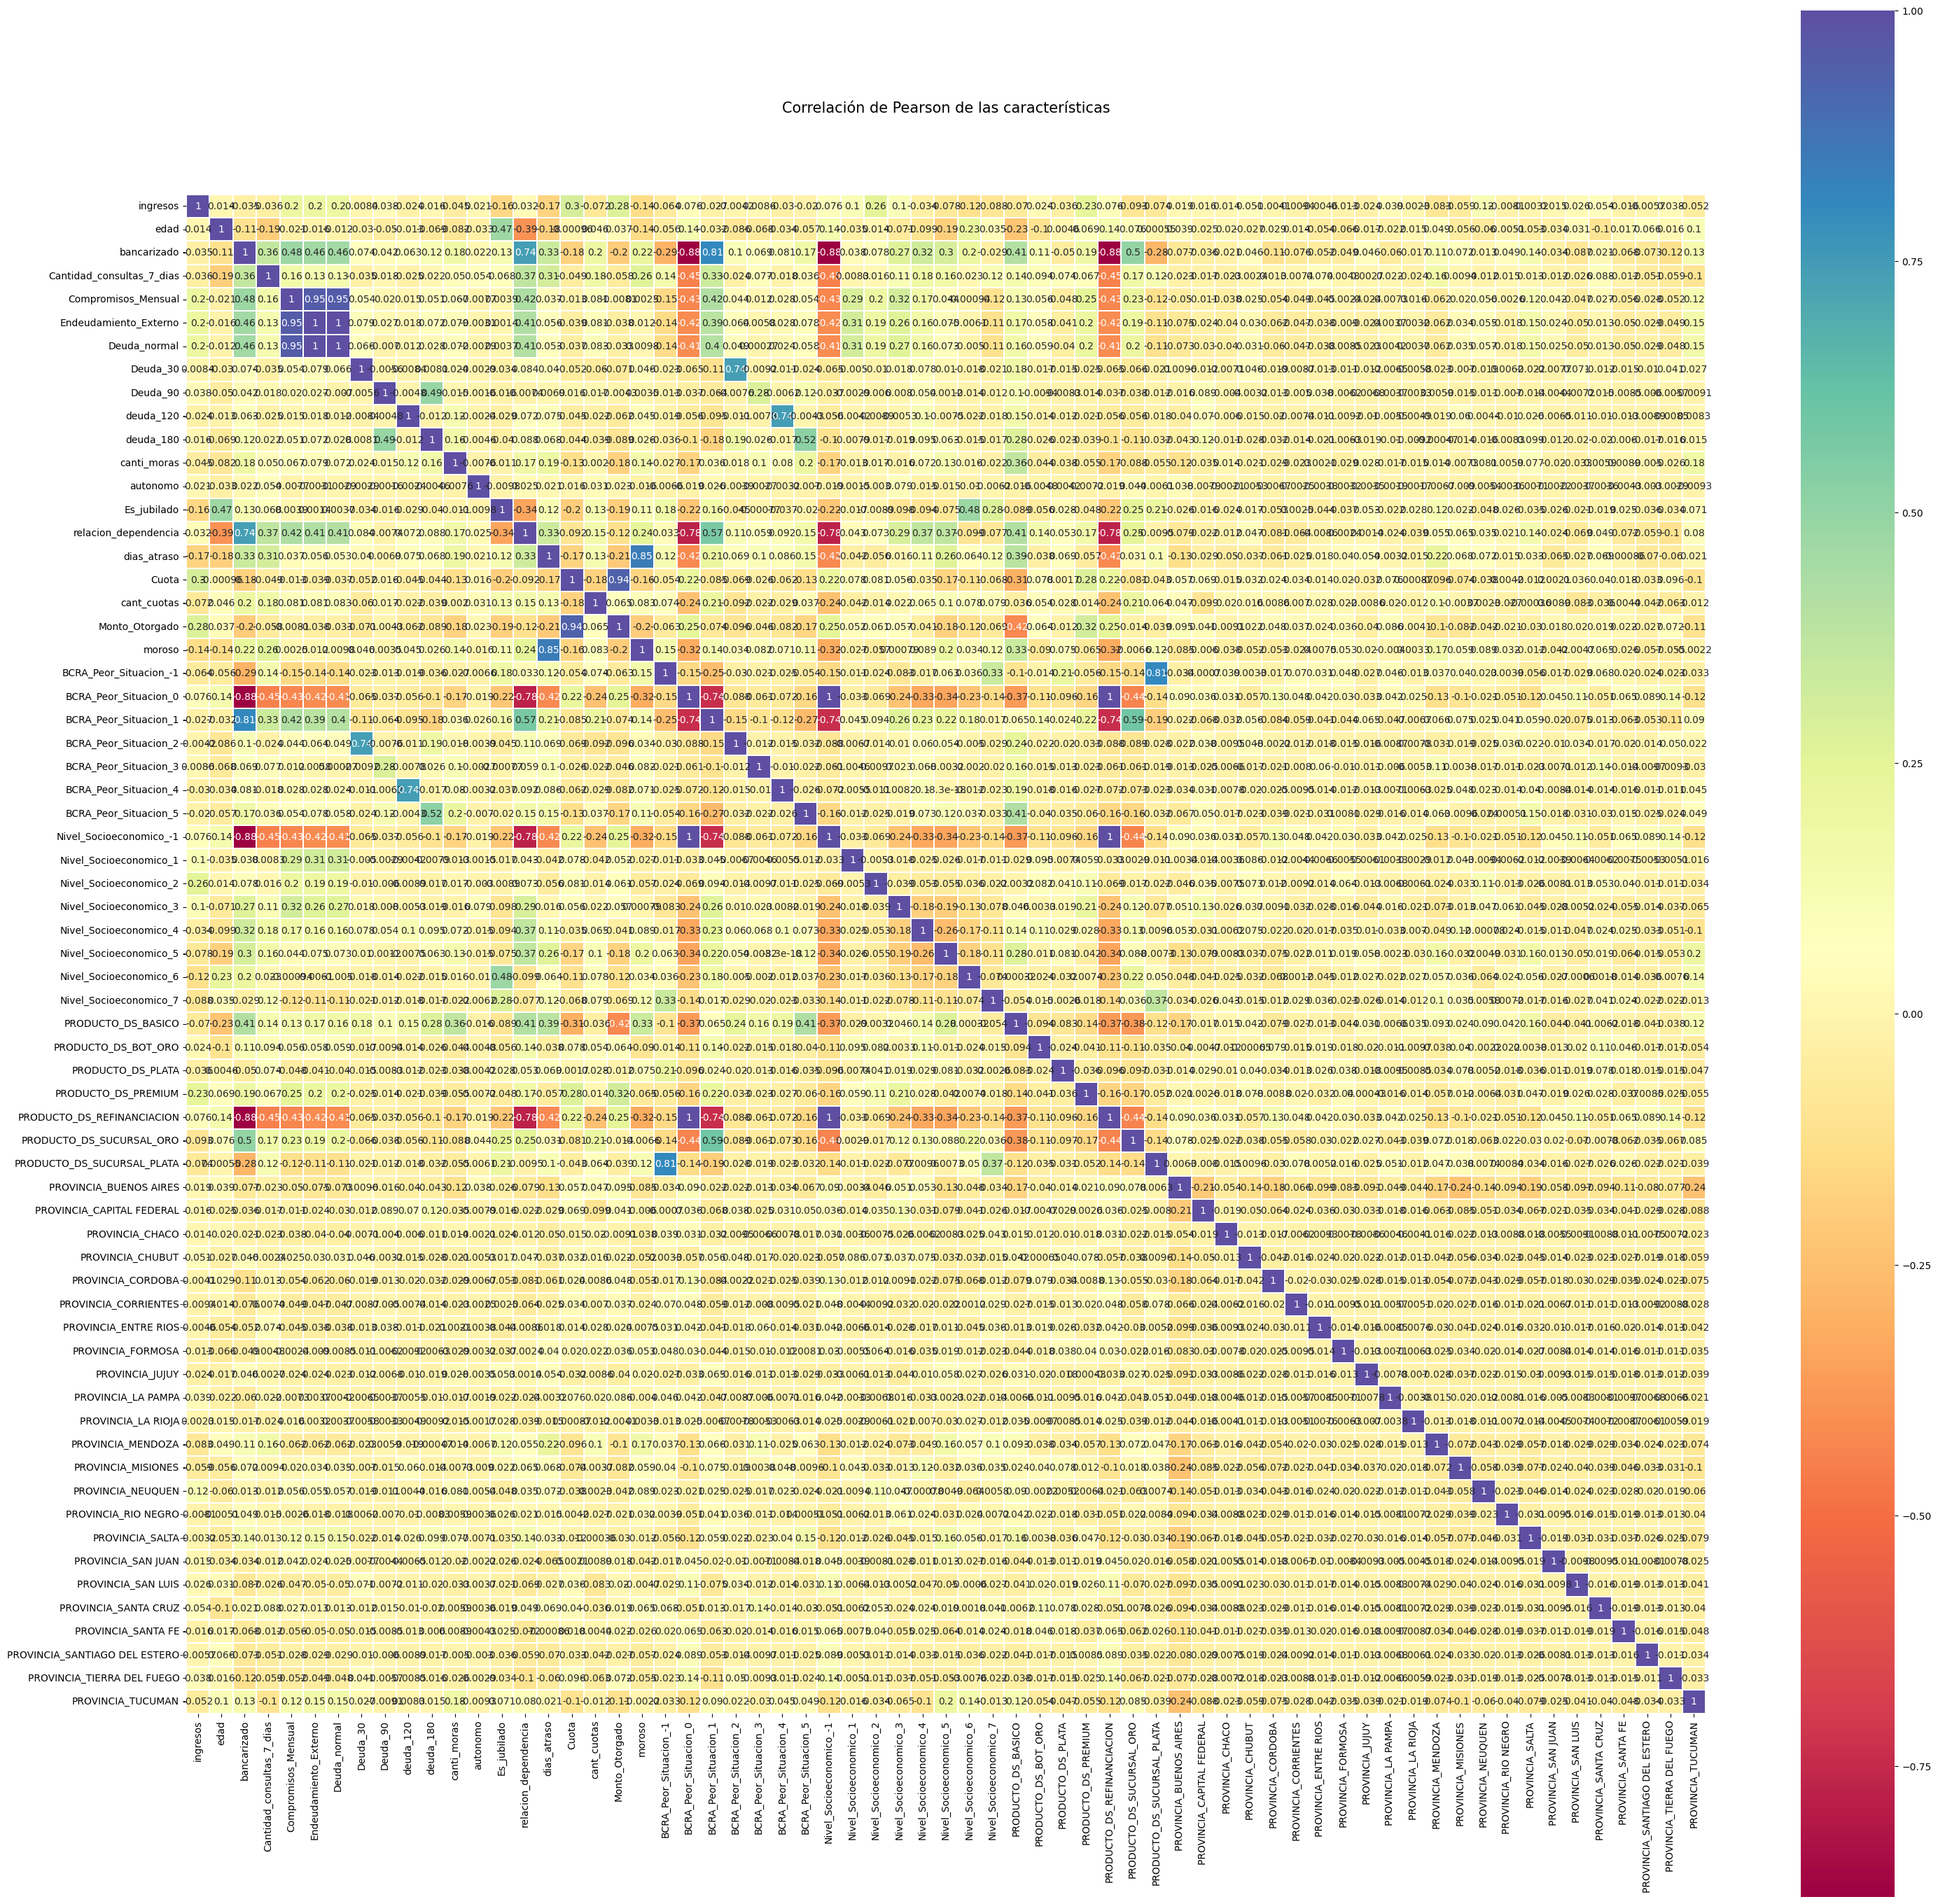

In [23]:
# VEMOS COMO QUEDARON LAS correlaciones EN EL DATASET. Usamos Pearson. Otra opción es Spearman.

plt.figure(figsize = (35,35))
plt.title('Correlación de Pearson de las características', y = 1.05, size = 15)
sns.heatmap(credito.corr(), linewidths = 0.1, vmax = 1.0, square = True,
            cmap = 'Spectral',linecolor = 'white', annot = True)
plt.show()


moroso
0    921
1    269
dtype: int64


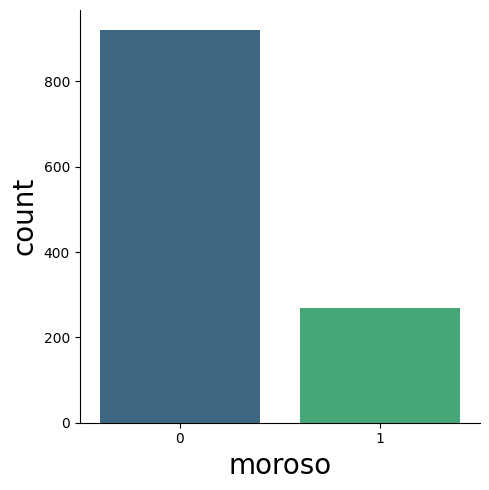

In [24]:
# Veamos como están distribuidas la categoría target 'moroso'
parameters = {'axes.labelsize': 20,
          'axes.titlesize': 20}
plt.rcParams.update(parameters)

print(credito.groupby('moroso').size())
sns.catplot(data=credito, x='moroso', kind = "count", palette='viridis')
# Existe desbalance entre ambas características

# Ya está listo el dataset para buscar y entrenar modelos
# Copiamos el dataframe original para no perder nada en otro y trabajamos sobre el otro
# Falta estandarizar las características
# Vamos a usar SVM, con distintos valores de C y gamma y distintos kernel, para encontrar el mejor modelo
# Armaremos un pipeline, pero primero separaremos en train y test

In [ ]:
# Primero lo haremos a la manera 'tradicional', separando en train y test
# pero además usaremos un cjto de validación para elegir el modelo
# Para separar en tres, se usa sklearn.train... dos veces:
# la primera separa train1 y test y la segunda sobre el train1, separa train y validation

cred=credito.copy()   # lo preservamos
y=np.array(cred['moroso'])    # definimos variable target
X=np.array(cred.drop(['moroso'], axis=1))   # definimos dataset de características puras

# stratify=y hace que respete la distribución de las clases en y para muestrear
X_train1, X_test, y_train1, y_test = train_test_split(X, y, test_size = 0.2, stratify=y,
                                                    random_state = 16)
X_train, X_val, y_train, y_val = train_test_split(X_train1, y_train1, test_size = 0.2, stratify=y_train1,
                                                  random_state = 16)

In [ ]:
X_train.shape

(761, 64)

In [ ]:
# Ahora vamos a buscar los parámetros para entrenar una máquina de soporte vectorial
# usaremos GridSearch, que viene con un cross validation incluido :)
# class sklearn.model_selection.GridSearchCV(estimator, param_grid, *, scoring=None,
# n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan,
# return_train_score=False)
param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
degree_range=[i+1 for i in range(5)]
print(degree_range)
param_grid = [{'svc__C': param_range,'svc__kernel': ['linear']},
              {'svc__C': param_range,'svc__gamma': param_range,'svc__kernel': ['rbf', 'poly', 'sigmoid'],'svc__degree':degree_range }]
svc = SVC(random_state=16)  # para que sea reproducible el resultado
pipe_svc = make_pipeline(StandardScaler(), svc)
# # 10 folds y todos los procesadores y que use el score de la svm
gs = GridSearchCV(estimator=pipe_svc, param_grid=param_grid, scoring=None, cv=10, n_jobs=-1)  # 10 folds y todos los procesadores
gs.fit(X_train, y_train)
print(f'Mejor score: {100*gs.best_score_} %')
print(f'Mejores parámetros: {gs.best_params_}')


[1, 2, 3, 4, 5]
Mejor score: 97.23855092276145 %
Mejores parámetros: {'svc__C': 100.0, 'svc__kernel': 'linear'}


tn, fp, fn, tp = [147   1   4  39]
Val_accuracy_svm= 97.38219895287958 %


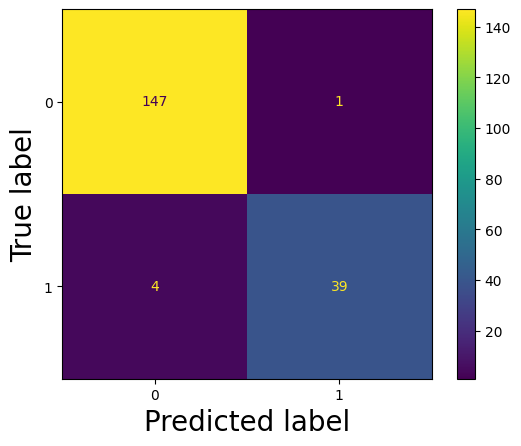

In [ ]:
# Veamos la matriz de confusión
svm=gs.best_estimator_        # elegimos el que mejor salió
svm.fit(X_train, y_train)     # entrenamos...
y_pred_sv=svm.predict(X_val)  # ... y predecimos sobre el cjto de validación
# matriz de confusión
print(f'tn, fp, fn, tp = {confusion_matrix(y_val, y_pred_sv).ravel()}')
# más 'bonita'
conf3 = confusion_matrix(y_val, y_pred_sv)
ConfusionMatrixDisplay(conf3).plot()
print(f'Val_accuracy_svm= {100*svm.score(X_val, y_val)} %')

tn, fp, fn, tp = [181   3   4  50]
Val_accuracy= 97.05882352941177 %


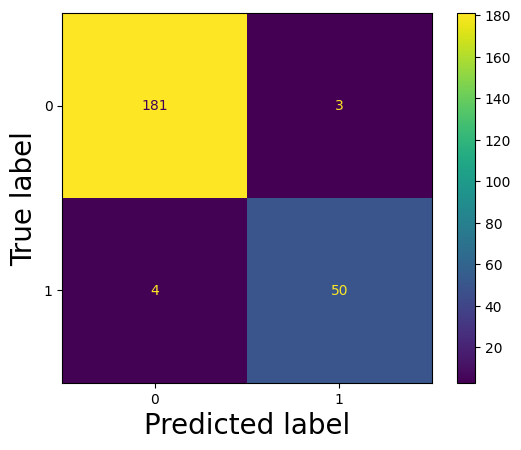

In [ ]:
# Ahora terminemos el trabajo, entrenando el que parece ser el mejor modelo pero sobre todo el cjto
# de entrenamiento 'train1' y luego veamos el rendimiento sobre el cjto de testeo 'test'

svm.fit(X_train1, y_train1)
y_pred1=svm.predict(X_test)
print(f'tn, fp, fn, tp = {confusion_matrix(y_test, y_pred1).ravel()}')
conf_svm = confusion_matrix(y_test, y_pred1)
ConfusionMatrixDisplay(conf_svm).plot()
print(f'Val_accuracy= {100*svm.score(X_test, y_test)} %')

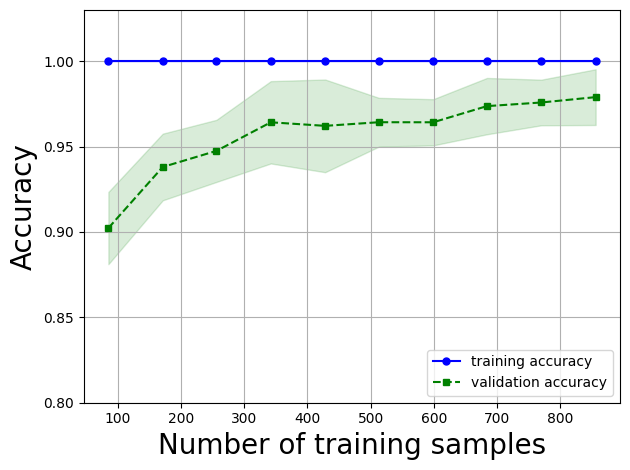

In [ ]:
# Veamos la curva de aprendizaje del modelo
train_sizes, train_scores, test_scores = learning_curve(estimator=svm,
                               X=X_train1,
                               y=y_train1,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.tight_layout()
#plt.savefig('image.png', dpi=300)
plt.show()


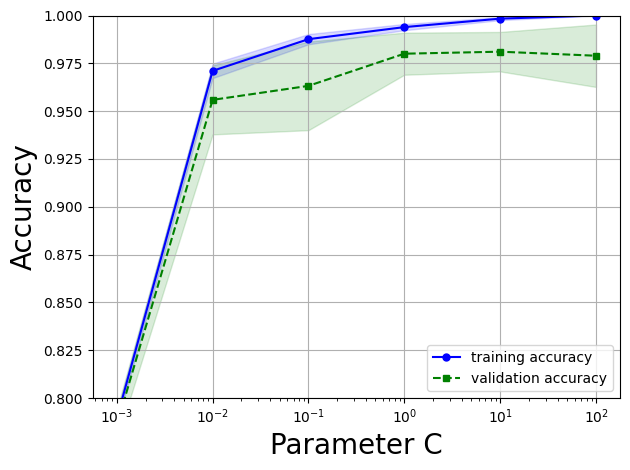

In [ ]:
# Analizar si hay sobreajuste o subajuste con curvas de validación
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = validation_curve(
                estimator=svm,
                X=X_train1,
                y=y_train1,
                param_name='svc__C',
                param_range=param_range,
                cv=10)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='training accuracy')

plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(param_range, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='validation accuracy')

plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1.0])
plt.tight_layout()
# plt.savefig('image.png', dpi=300)
plt.show()
